**EDA(Exploratory Data Analysis)**

**1. Setup & Load Clean Data**

In [ ]:

# STEP 1: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Load the cleaned dataset
df = pd.read_csv('/content/DataCoSupplyChain_clean.csv', parse_dates=['order date (DateOrders)', 'shipping date (DateOrders)'])
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print(df.head(3))

Shape: (180519, 51)
Columns: ['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Ship

**2. Statistical Summary**

In [ ]:
print(df.describe().T)

# Key columns analysis
key_cols = ['sales', 'profit', 'quantity', 'discount_rate',
            'days_shipped_actual', 'shipping_delay']

for col in key_cols:
  if col in df.columns:
    print(f'\n--- {col} ---')
    print(f' Mean: {df[col].mean():.2f}')
    print(f' Median: {df[col].median():.2f}')
    print(f' Std: {df[col].std():.2f}')
    print(f' Min: {df[col].min():.2f}')
    print(f' Max: {df[col].max():.2f}')
    print(f' Skew: {df[col].skew():.2f}')

        # Count unique values in categorical columns
cat_cols = ['shipping_mode', 'customer_segment', 'market',
'category_name', 'Delivery Status']
for col in cat_cols:
  if col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')
    print(df[col].value_counts(normalize=True).round(3) * 100)


                                  count                           mean  \
Days for shipping (real)       180519.0                       3.497654   
Days for shipment (scheduled)  180519.0                       2.931847   
Benefit per order              180519.0                      21.974989   
Sales per customer             180519.0                     183.107609   
Late_delivery_risk             180519.0                       0.548291   
Category Id                    180519.0                      31.851451   
Customer Id                    180519.0                    6691.379495   
Customer Zipcode               180519.0                   35920.541998   
Department Id                  180519.0                        5.44346   
Latitude                       180519.0                      29.719955   
Longitude                      180519.0                     -84.915675   
Order Customer Id              180519.0                    6691.379495   
order date (DateOrders)          18051

**3. Univariate Analysis — One Column at a Time**

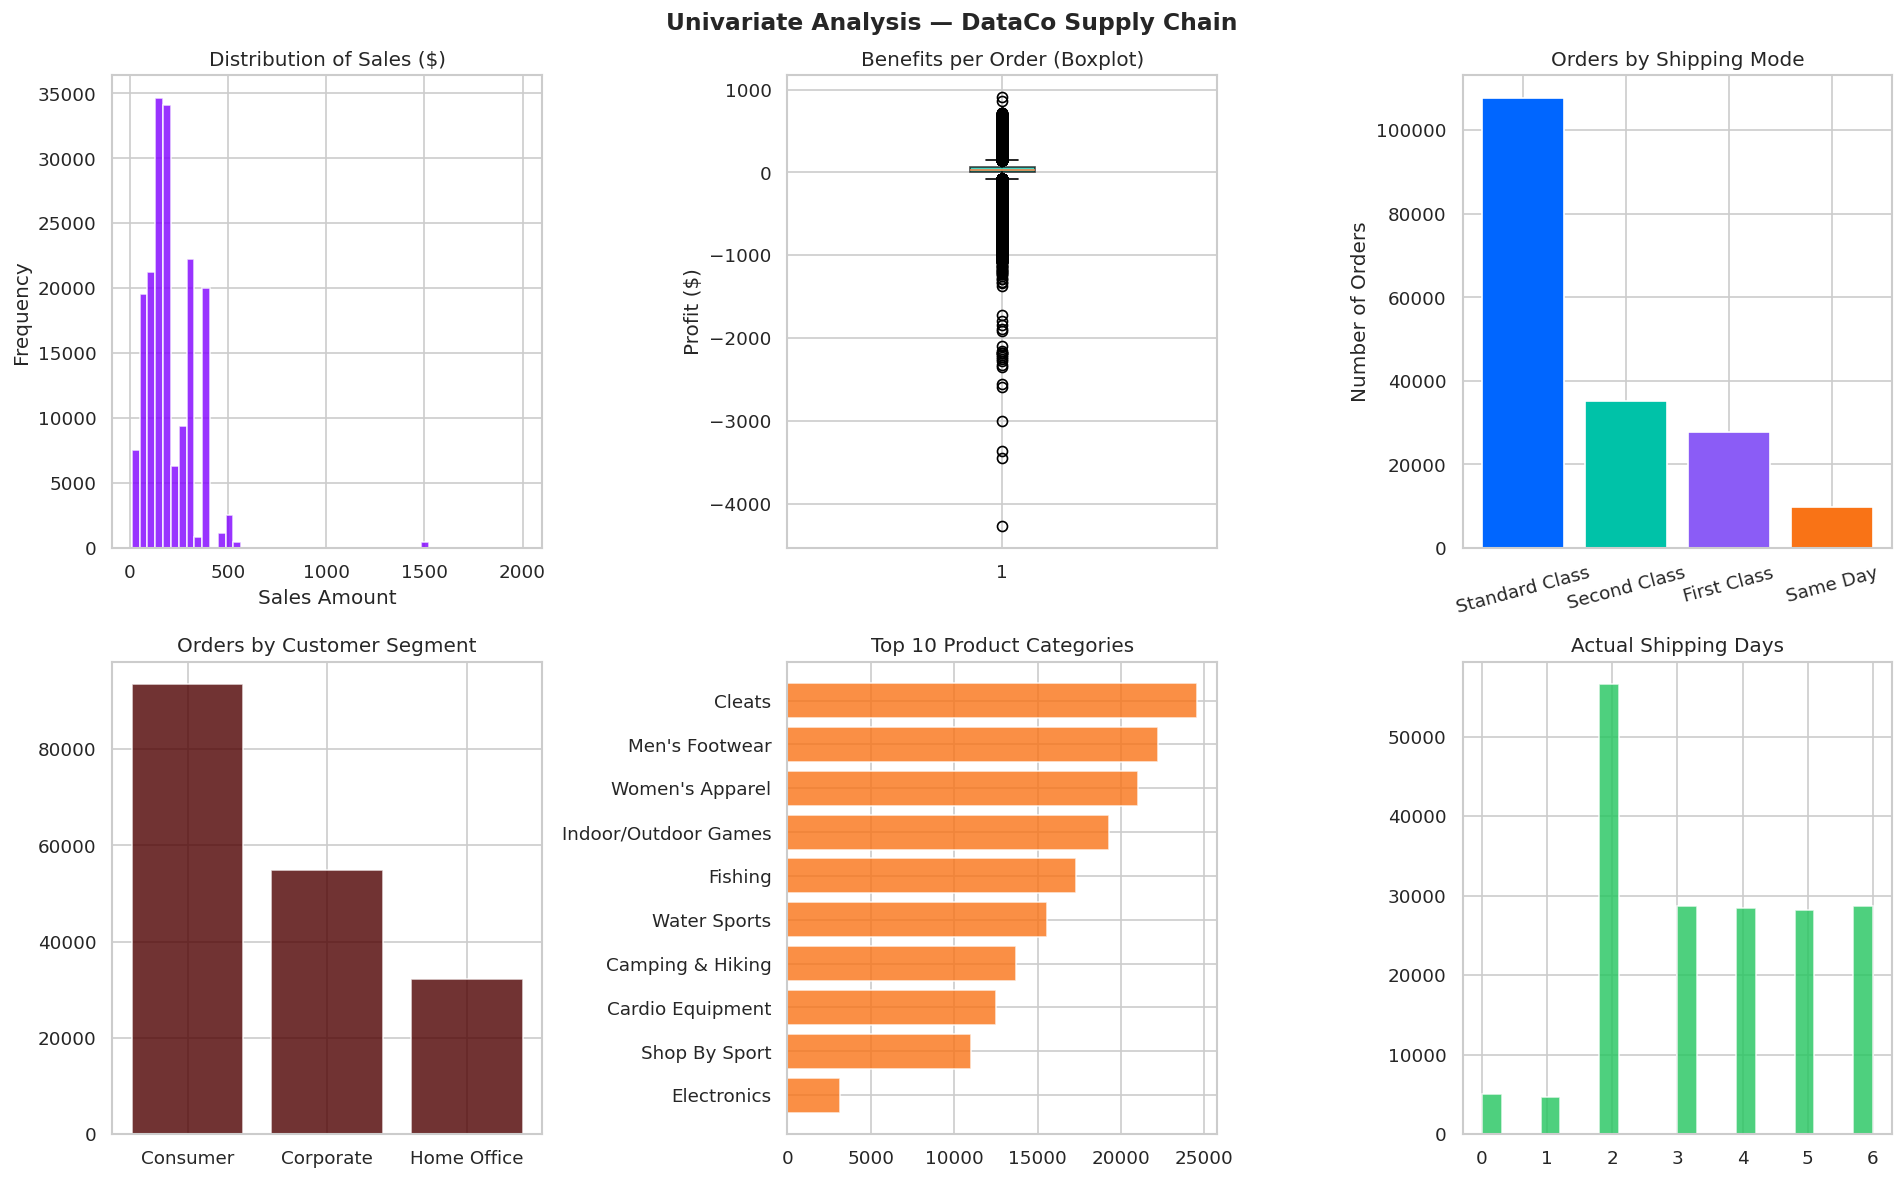

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Univariate Analysis — DataCo Supply Chain', fontsize=14, fontweight='bold')

# 1. Histogram: Sales distribution
axes[0,0].hist(df['Sales'].dropna(), bins=50, color='#8000ff', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Distribution of Sales ($)')
axes[0,0].set_xlabel('Sales Amount')
axes[0,0].set_ylabel('Frequency')

# 2. Boxplot: Profit
axes[0,1].boxplot(df['Benefit per order'].dropna(), patch_artist=True,
boxprops=dict(facecolor='#00C2A8', alpha=0.7))
axes[0,1].set_title('Benefits per Order (Boxplot)')
axes[0,1].set_ylabel('Profit ($)')

# 3. Bar chart: Shipping mode
ship_counts = df['Shipping Mode'].value_counts()
axes[0,2].bar(ship_counts.index, ship_counts.values,
color=['#0066FF','#00C2A8','#8B5CF6','#F97316'])
axes[0,2].set_title('Orders by Shipping Mode')
axes[0,2].set_ylabel('Number of Orders')
axes[0,2].tick_params(axis='x', rotation=15)

# 4. Bar chart: Customer segment
seg_counts = df['Customer Segment'].value_counts()
axes[1,0].bar(seg_counts.index, seg_counts.values, color='#4d0000', alpha=0.8)
axes[1,0].set_title('Orders by Customer Segment')

# 5. Top 10 categories
top_cats = df['Category Name'].value_counts().head(10)
axes[1,1].barh(top_cats.index, top_cats.values, color='#F97316', alpha=0.8)
axes[1,1].set_title('Top 10 Product Categories')
axes[1,1].invert_yaxis()

# 6. Histogram: Shipping days
axes[1,2].hist(df['Days for shipping (real)'].dropna(), bins=20,
color='#22C55E', edgecolor='white', alpha=0.8)
axes[1,2].set_title('Actual Shipping Days')
plt.tight_layout()
plt.savefig('outputs/univariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**4. Bivariate Analysis — Two Columns Together**

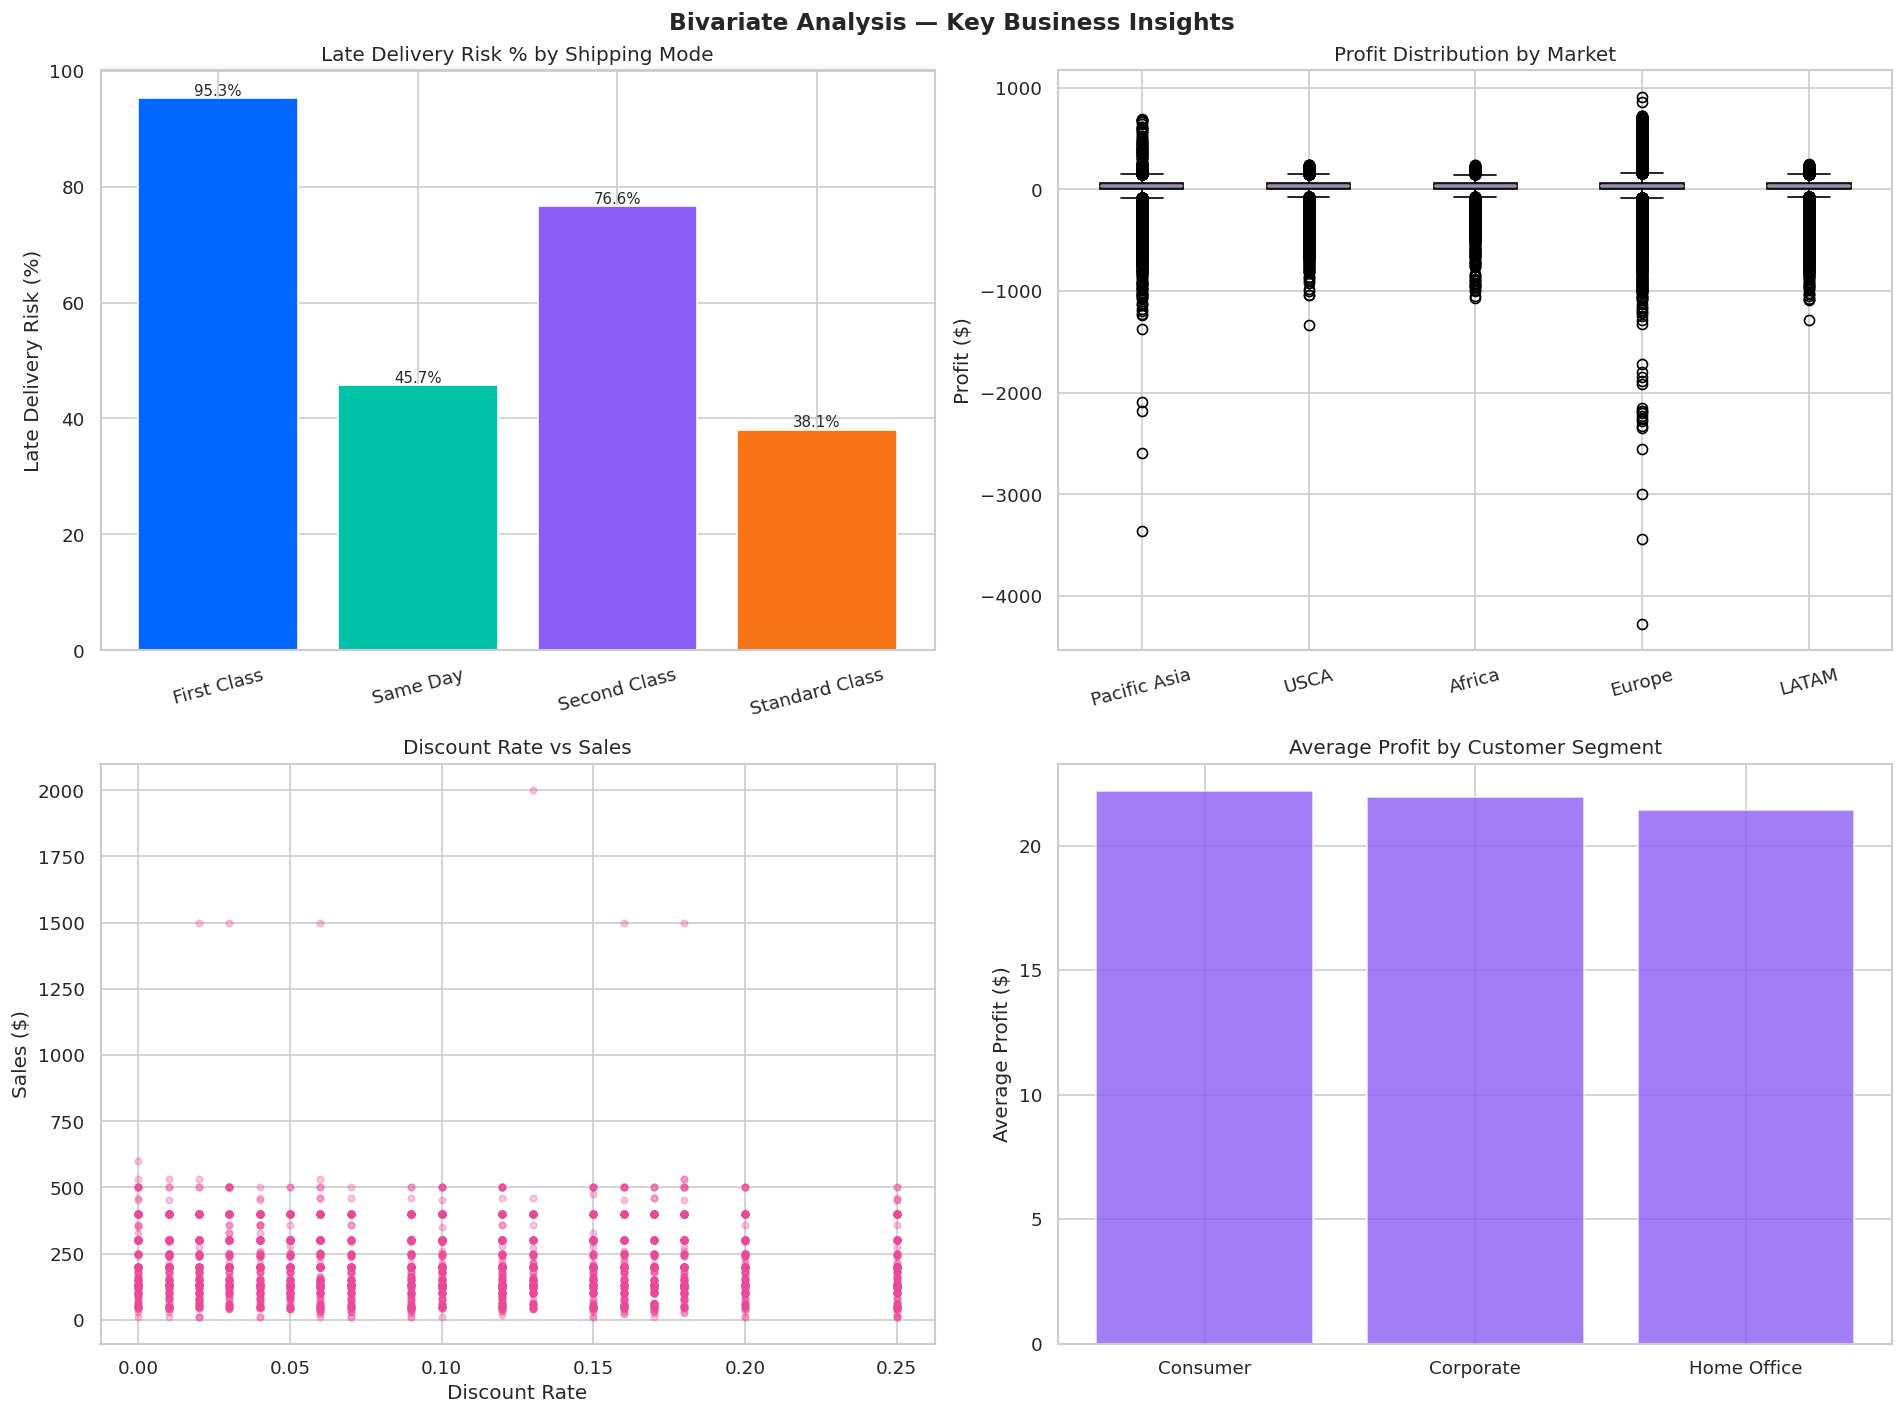

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Bivariate Analysis — Key Business Insights', fontsize=14, fontweight='bold')

# 1. Shipping Mode vs Late Delivery Risk
ship_delay = df.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100
axes[0,0].bar(ship_delay.index, ship_delay.values,
color=['#0066FF','#00C2A8','#8B5CF6','#F97316'])
axes[0,0].set_title('Late Delivery Risk % by Shipping Mode')
axes[0,0].set_ylabel('Late Delivery Risk (%)')
axes[0,0].tick_params(axis='x', rotation=15)
for i, v in enumerate(ship_delay.values):
  axes[0,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# 2. Market vs Profit (Boxplot)
markets = df['Market'].unique()
data_by_market = [df[df['Market']==m]['Benefit per order'].dropna() for m in markets]
axes[0,1].boxplot(data_by_market, labels=markets, patch_artist=True)
axes[0,1].set_title('Profit Distribution by Market')
axes[0,1].set_ylabel('Profit ($)')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Discount Rate vs Sales (Scatter)
sample = df.sample(3000, random_state=42) # sample for speed
axes[1,0].scatter(sample['Order Item Discount Rate'], sample['Sales'],
alpha=0.3, color='#EC4899', s=15)
axes[1,0].set_title('Discount Rate vs Sales')
axes[1,0].set_xlabel('Discount Rate')
axes[1,0].set_ylabel('Sales ($)')

# 4. Customer Segment vs Profit Margin
seg_profit = df.groupby('Customer Segment')['Benefit per order'].mean()
axes[1,1].bar(seg_profit.index, seg_profit.values,
color='#8B5CF6', alpha=0.8)
axes[1,1].set_title('Average Profit by Customer Segment')
axes[1,1].set_ylabel('Average Profit ($)')
plt.tight_layout()
plt.savefig('outputs/bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

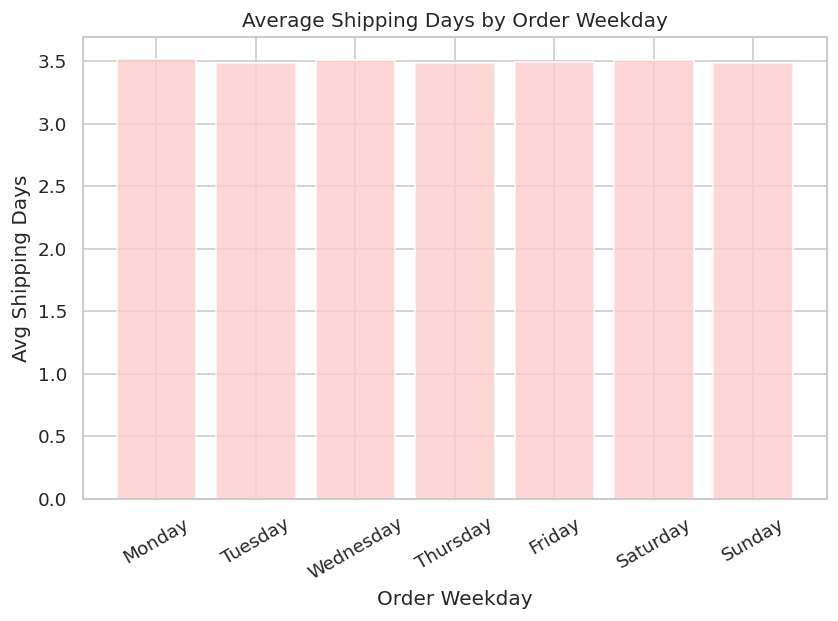

In [ ]:
#5. If order_weekday not created yet, create it
df['order_weekday'] = df['order date (DateOrders)'].dt.day_name()

# Define correct weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday',
                 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate average shipping days per weekday
weekday_shipping = df.groupby('order_weekday')['Days for shipping (real)'].mean()
weekday_shipping = weekday_shipping.reindex(weekday_order)

plt.figure(figsize=(8,5))
plt.bar(weekday_shipping.index,
        weekday_shipping.values,
        color='#ffcccc', alpha=0.8)

plt.title("Average Shipping Days by Order Weekday")
plt.xlabel("Order Weekday")
plt.ylabel("Avg Shipping Days")
plt.xticks(rotation=30)
plt.show()

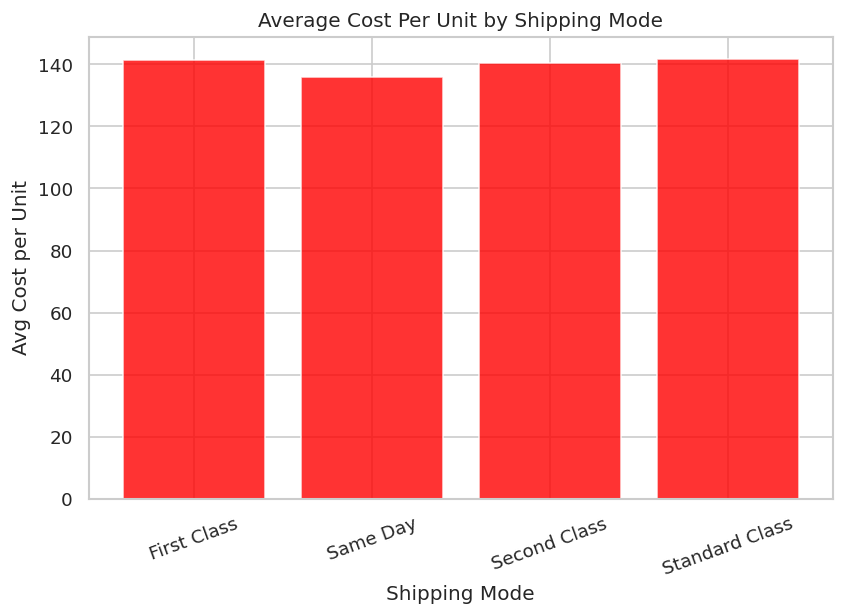

In [ ]:
#6. Create cost per unit column
df['cost_per_unit'] = df['Sales'] / df['Order Item Quantity']

# Calculate average cost per unit per shipping mode
shipping_cost = df.groupby('Shipping Mode')['cost_per_unit'].mean()

plt.figure(figsize=(8,5))
plt.bar(shipping_cost.index,
        shipping_cost.values,
        color='#ff0000', alpha=0.8)

plt.title("Average Cost Per Unit by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Avg Cost per Unit")
plt.xticks(rotation=20)
plt.show()

**5. Time Series Analysis — Trends Over Time**

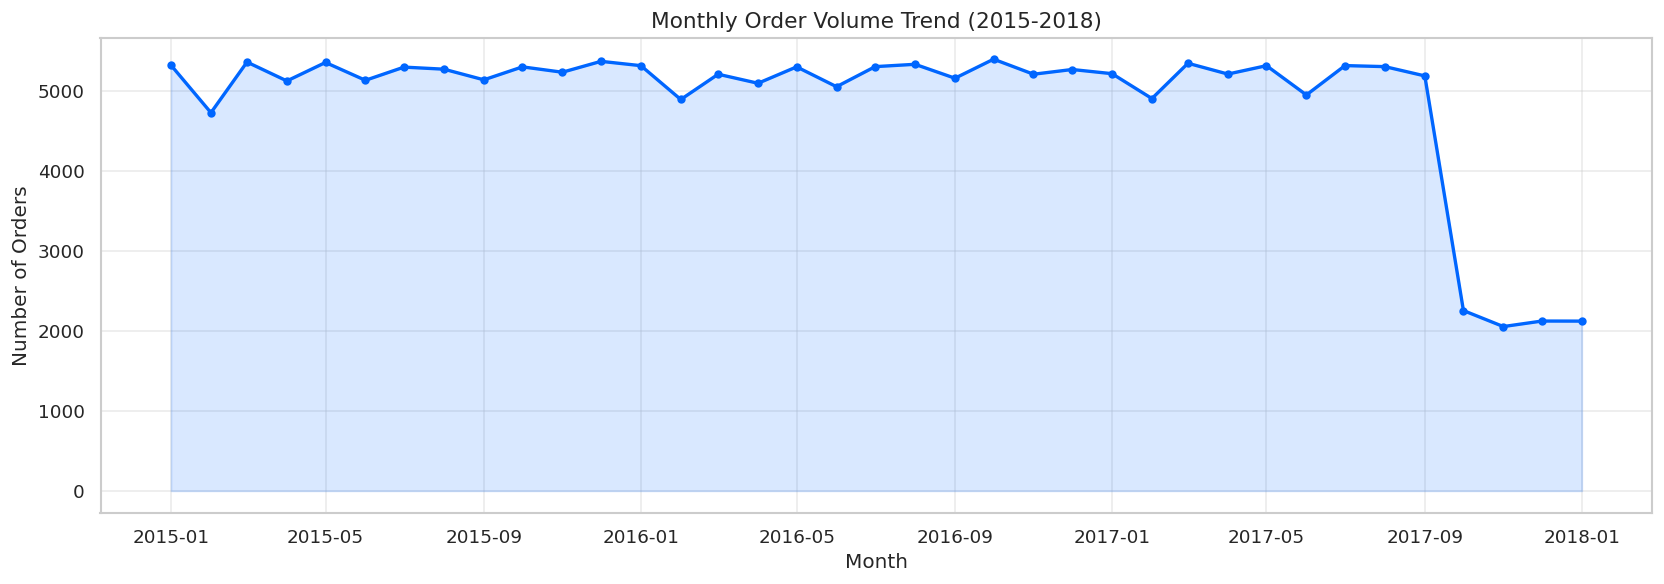

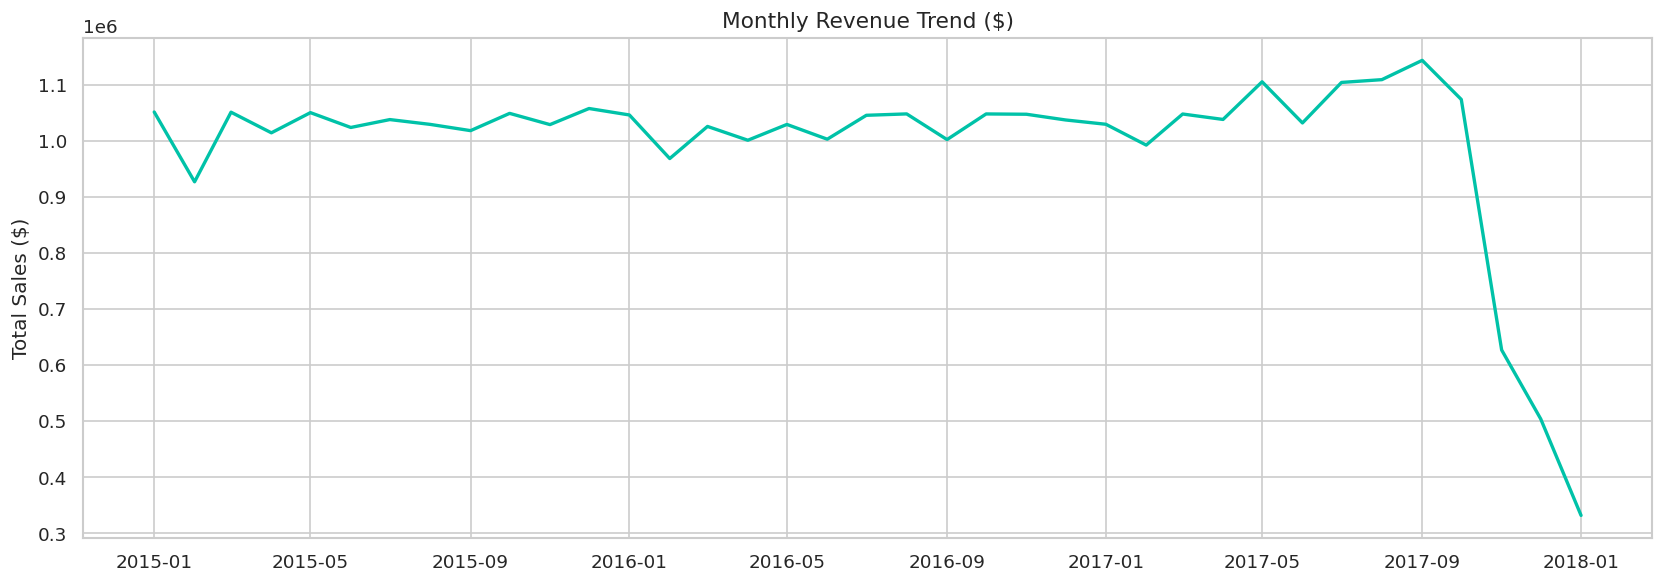

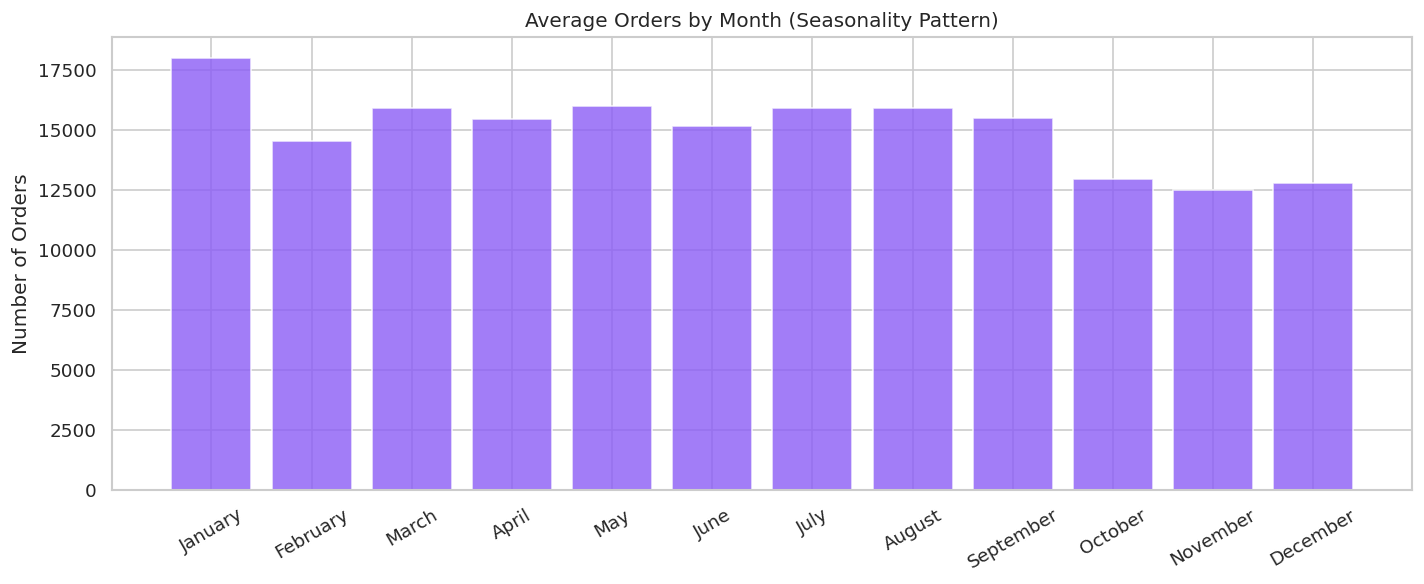

In [ ]:
# Monthly order volume trend
monthly_orders = df.groupby(df['order date (DateOrders)'].dt.to_period('M')).size()
monthly_orders.index = monthly_orders.index.to_timestamp()
plt.figure(figsize=(14, 5))
plt.plot(monthly_orders.index, monthly_orders.values,
color='#0066FF', linewidth=2, marker='o', markersize=4)
plt.fill_between(monthly_orders.index, monthly_orders.values,
                 alpha=0.15, color='#0066FF')
plt.title('Monthly Order Volume Trend (2015-2018)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('outputs/monthly_orders_trend.png', dpi=150)
plt.show()

# Monthly revenue trend
monthly_sales = df.groupby(df['order date (DateOrders)'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales.index, monthly_sales.values,
color='#00C2A8', linewidth=2)
plt.title('Monthly Revenue Trend ($)', fontsize=13)
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('outputs/monthly_revenue_trend.png', dpi=150)
plt.show()

# Seasonal pattern — orders by month of year
df['month_name'] = df['order date (DateOrders)'].dt.month_name()
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_avg = df.groupby('month_name').size().reindex(month_order)
plt.figure(figsize=(12, 5))
plt.bar(monthly_avg.index, monthly_avg.values, color='#8B5CF6', alpha=0.8)
plt.title('Average Orders by Month (Seasonality Pattern)')
plt.xticks(rotation=30)
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('outputs/seasonality_pattern.png', dpi=150)
plt.show()

**6. Delivery Performance Analysis**

Overall Late Delivery Rate: 54.8%


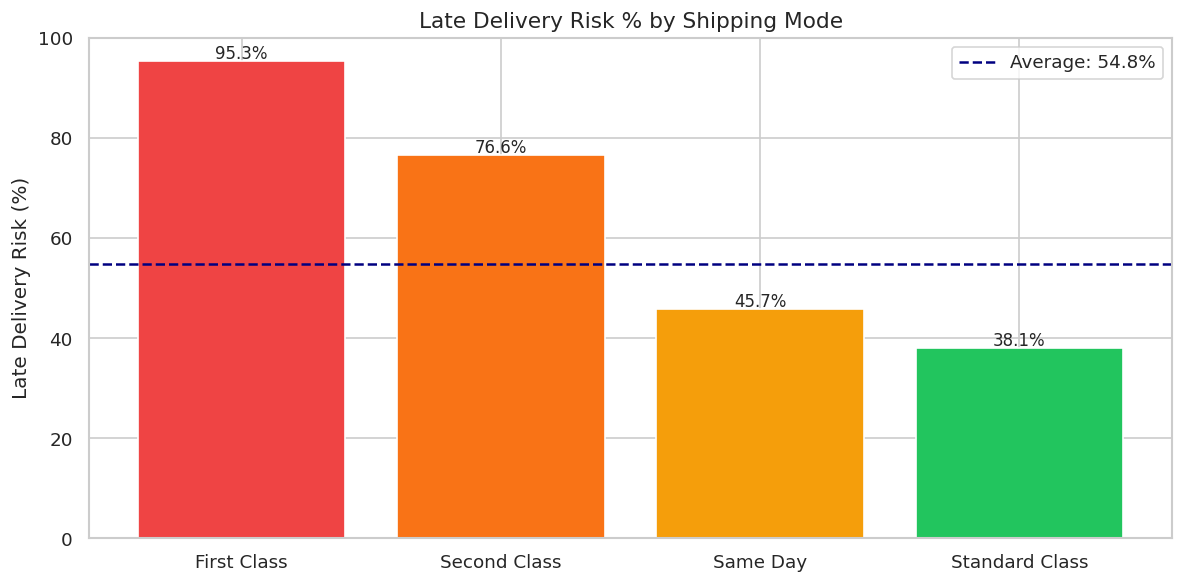

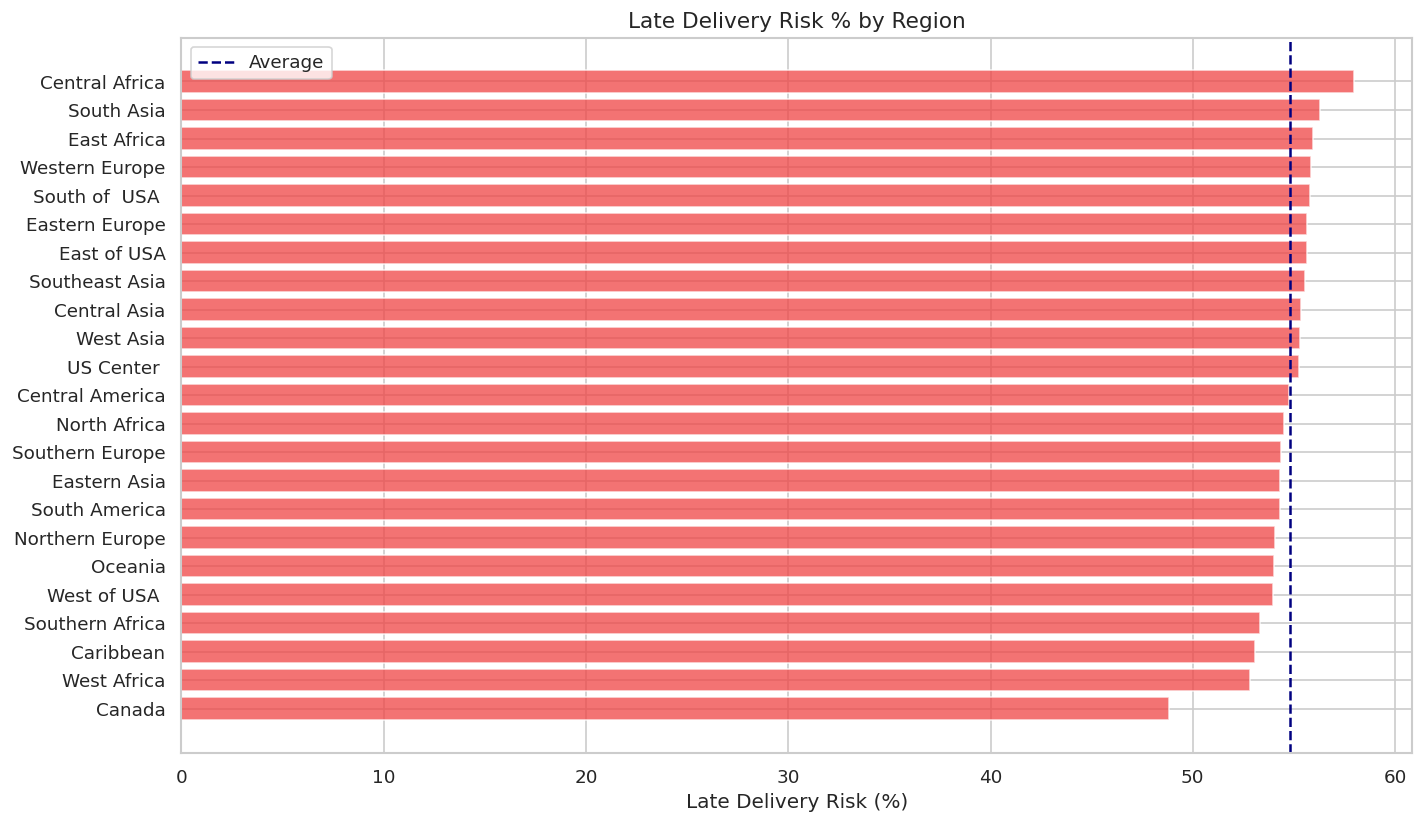

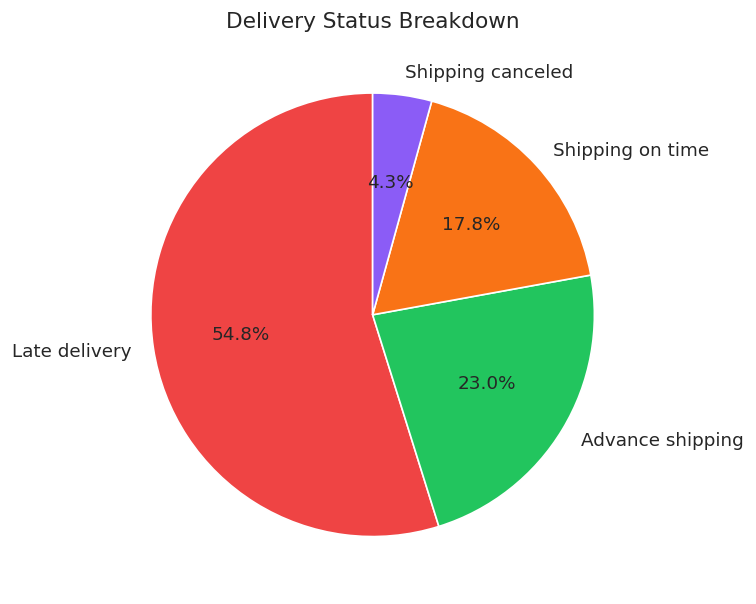

In [ ]:
# Overall late delivery rate
late_rate = df['Late_delivery_risk'].mean() * 100
print(f'Overall Late Delivery Rate: {late_rate:.1f}%')

# Late delivery rate by Shipping Mode
late_by_ship = df.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100
late_by_ship = late_by_ship.sort_values(ascending=False)
plt.figure(figsize=(10, 5))
bars = plt.bar(late_by_ship.index, late_by_ship.values,
color=['#EF4444','#F97316','#F59E0B','#22C55E']) # Changed '#AMBER' to a valid hex code
plt.title('Late Delivery Risk % by Shipping Mode', fontsize=13)
plt.ylabel('Late Delivery Risk (%)')
plt.axhline(y=late_rate, color='navy', linestyle='--', label=f'Average: {late_rate:.1f}%')
plt.legend()
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
f'{bar.get_height():.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/late_delivery_by_shipping.png', dpi=150)
plt.show()

# Late delivery by Region
late_by_region = df.groupby('Order Region')['Late_delivery_risk'].mean() * 100
late_by_region = late_by_region.sort_values(ascending=True)
plt.figure(figsize=(12, 7))
plt.barh(late_by_region.index, late_by_region.values, color='#EF4444', alpha=0.75)
plt.title('Late Delivery Risk % by Region', fontsize=13)
plt.xlabel('Late Delivery Risk (%)')
plt.axvline(x=late_rate, color='navy', linestyle='--', label='Average')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/late_delivery_by_region.png', dpi=150)
plt.show()

# Delivery status breakdown (pie chart)
status_counts = df['Delivery Status'].value_counts()
colors_pie = ['#EF4444','#22C55E','#F97316','#8B5CF6']
plt.figure(figsize=(8, 6))
plt.pie(status_counts.values, labels=status_counts.index,
autopct='%1.1f%%', colors=colors_pie, startangle=90)
plt.title('Delivery Status Breakdown', fontsize=13)
plt.savefig('outputs/delivery_status_pie.png', dpi=150)
plt.show()

**7. Profitability Analysis**


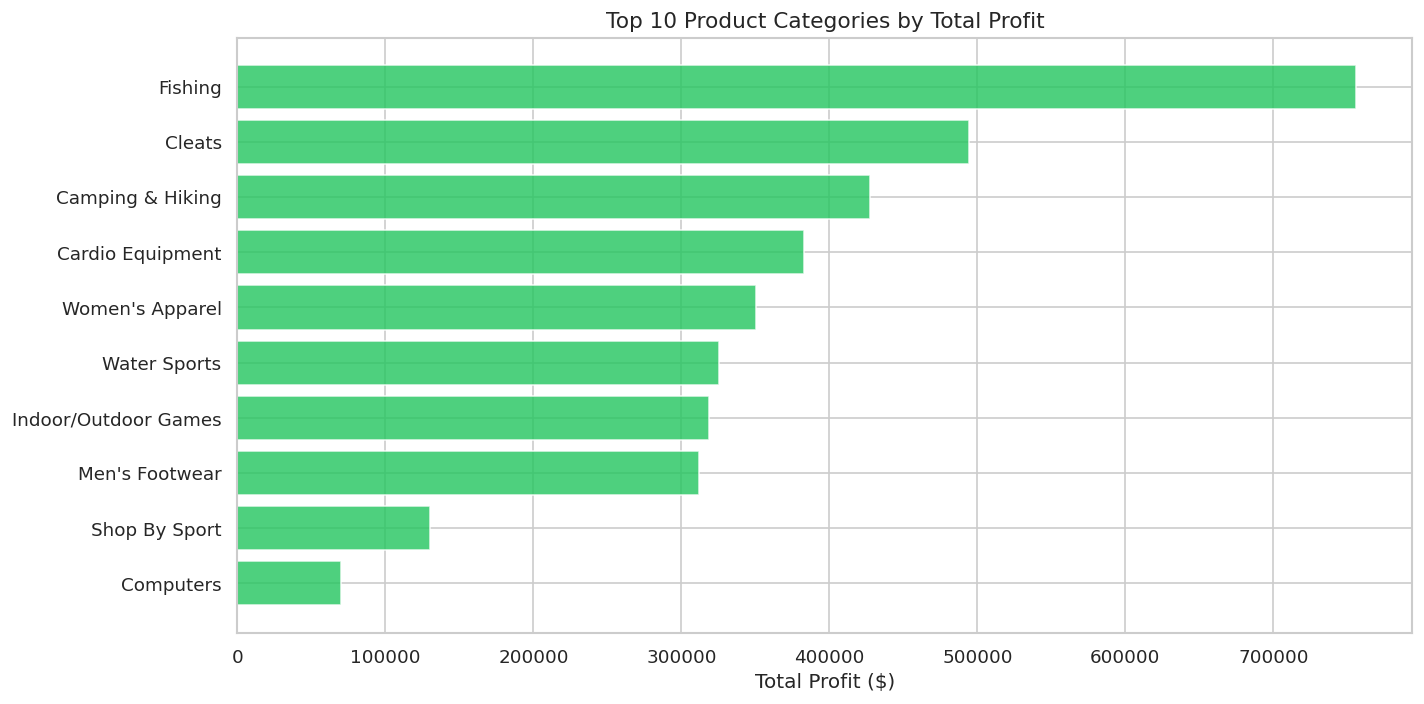


Profit by Market:
              total_profit  avg_profit  total_orders
Market                                              
Europe          1169442.96       23.27         50252
LATAM           1123321.61       21.77         51594
Pacific Asia     857753.44       20.79         41260
USCA             564313.78       21.87         25799
Africa           252071.18       21.70         11614

Loss-making orders: 33784 (18.7%)
Top categories with losses:
Category Name
Cleats                  4590
Men's Footwear          4169
Women's Apparel         3923
Indoor/Outdoor Games    3617
Fishing                 3209
Name: count, dtype: int64


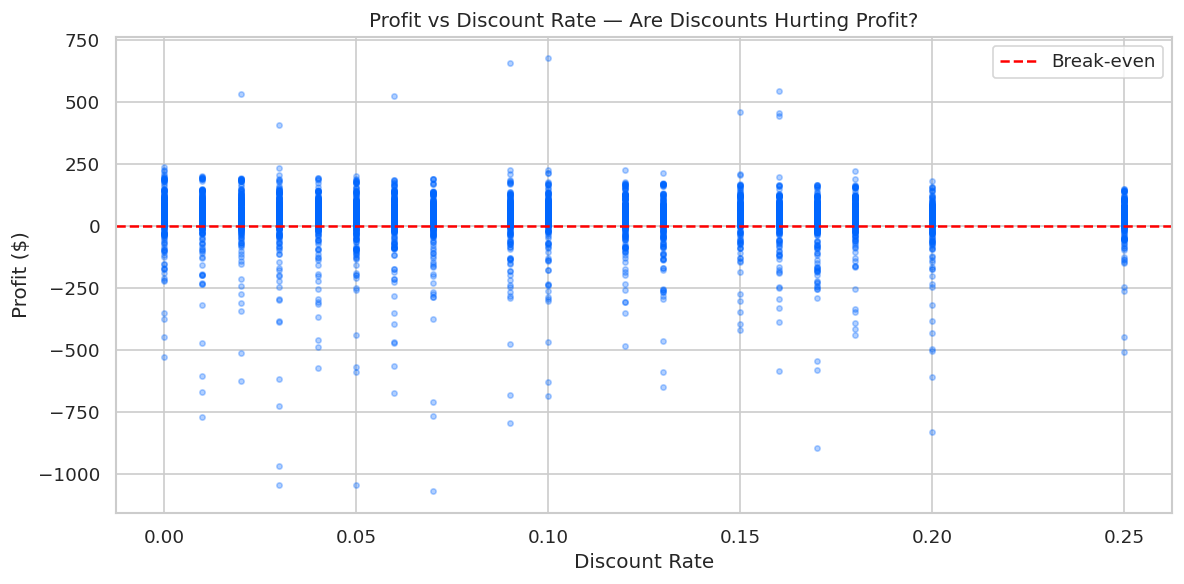

In [ ]:
# Top 10 most profitable product categories
cat_profit = df.groupby('Category Name')['Benefit per order'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.barh(cat_profit.index[::-1], cat_profit.values[::-1], color='#22C55E', alpha=0.8)
plt.title('Top 10 Product Categories by Total Profit', fontsize=13)
plt.xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('outputs/top_categories_profit.png', dpi=150)
plt.show()

# Profit by Market
market_profit = df.groupby('Market').agg(
total_profit=('Benefit per order', 'sum'),avg_profit=('Benefit per order', 'mean'),
total_orders=('Benefit per order', 'count')
).round(2)
print('\nProfit by Market:')
print(market_profit.sort_values('total_profit', ascending=False))

# Loss-making orders analysis
loss_orders = df[df['Benefit per order'] < 0]
print(f'\nLoss-making orders: {len(loss_orders)} ({len(loss_orders)/len(df)*100:.1f}%)')
print('Top categories with losses:')
print(loss_orders['Category Name'].value_counts().head(5))

# Profit vs Discount Rate (are discounts hurting profit?)
plt.figure(figsize=(10, 5))
sample = df.sample(5000, random_state=42)
plt.scatter(sample['Order Item Discount Rate'], sample['Benefit per order'],
alpha=0.3, color='#0066FF', s=10)
plt.axhline(y=0, color='red', linestyle='--', label='Break-even')
plt.title('Profit vs Discount Rate — Are Discounts Hurting Profit?')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/profit_vs_discount.png', dpi=150)
plt.show()

**8. Correlation Heatmap**

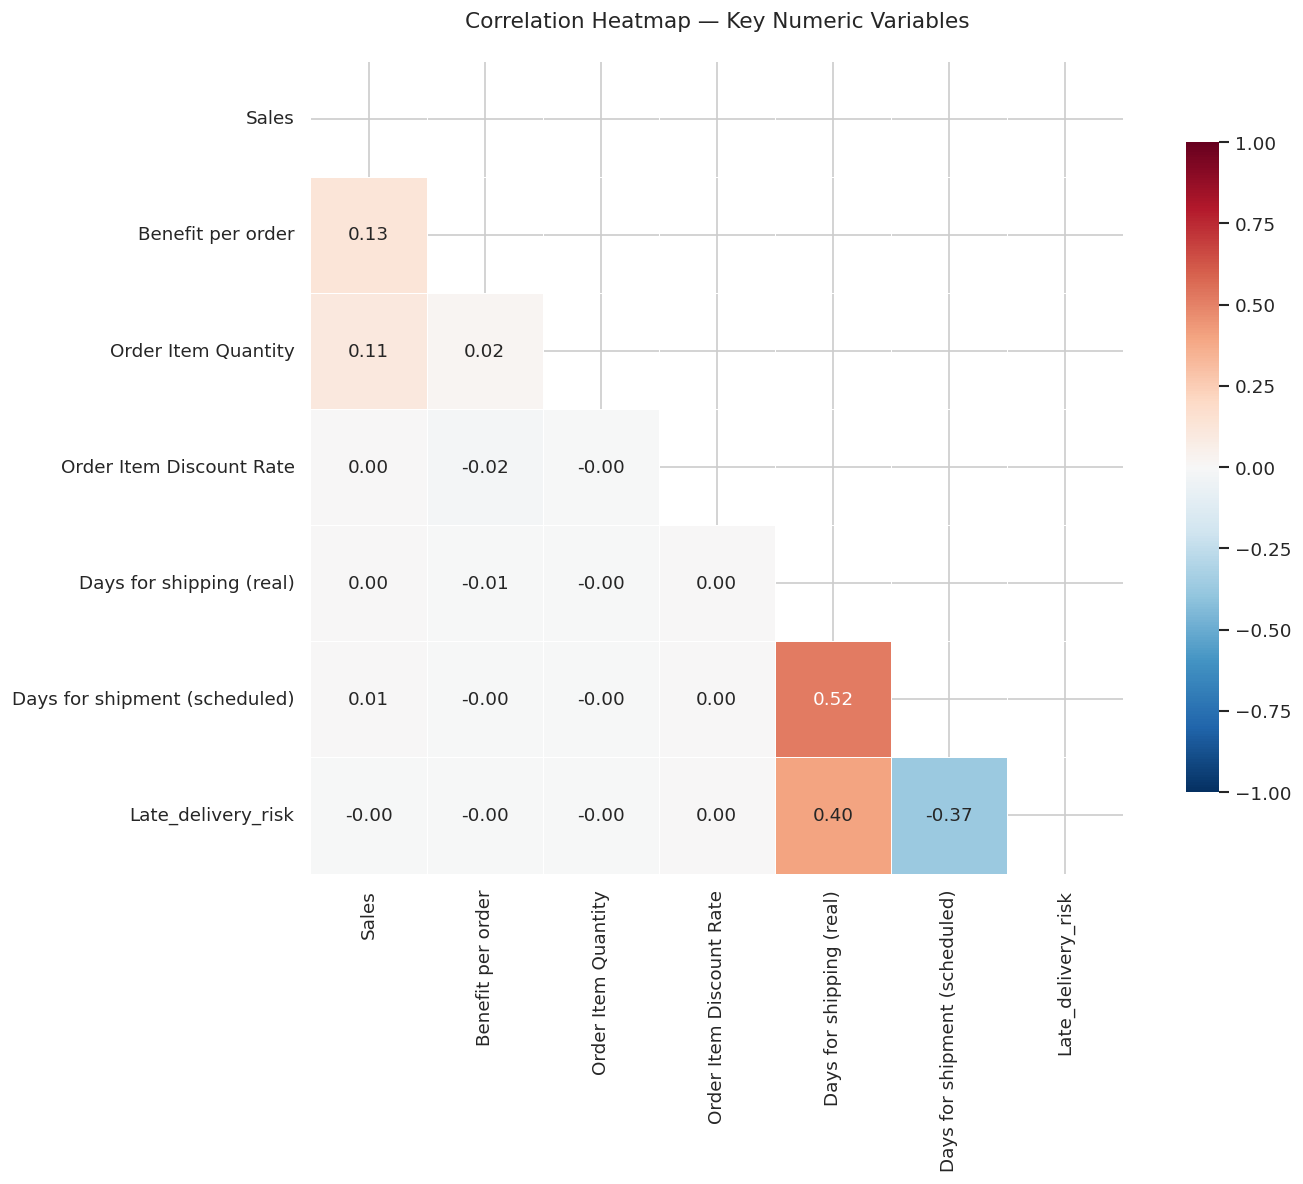


Features most correlated with Late_delivery_risk:
Days for shipping (real)         0.401415
Days for shipment (scheduled)    0.369352
Benefit per order                0.003727
Sales                            0.003564
Order Item Discount Rate         0.000404
Name: Late_delivery_risk, dtype: float64


In [ ]:
# Select key numeric columns for correlation
corr_cols = ['Sales', 'Benefit per order', 'Order Item Quantity', 'Order Item Discount Rate',
'Days for shipping (real)', 'Days for shipment (scheduled)',
'Late_delivery_risk'] # Removed 'shipping_delay', 'order_month', 'profit_margin_pct' as they are not direct columns or need creation
corr_cols = [c for c in corr_cols if c in df.columns]

# Compute correlation matrix
corr_matrix = df[corr_cols].corr()
# Plot heatmap
plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # show only lower triangle
sns.heatmap(
corr_matrix,
mask=mask,
annot=True,
fmt='.2f',
cmap='RdBu_r',
center=0,
vmin=-1, vmax=1,
square=True,
linewidths=0.5,
cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Key Numeric Variables', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with Late_delivery_risk
if 'Late_delivery_risk' in corr_matrix.columns:
    target_corr = corr_matrix['Late_delivery_risk'].abs().sort_values(ascending=False)
    print('\nFeatures most correlated with Late_delivery_risk:')
    print(target_corr[1:6]) # skip self-correlation

**9. Regional & Geographic Analysis**

              orders      revenue  avg_profit  late_pct
Market                                                 
Europe         50252  10872396.80       23.27      55.0
LATAM          51594  10277612.84       21.77      54.0
Pacific Asia   41260   8273743.74       20.79      55.0
USCA           25799   5066528.71       21.87      55.0
Africa         11614   2294452.93       21.70      55.0


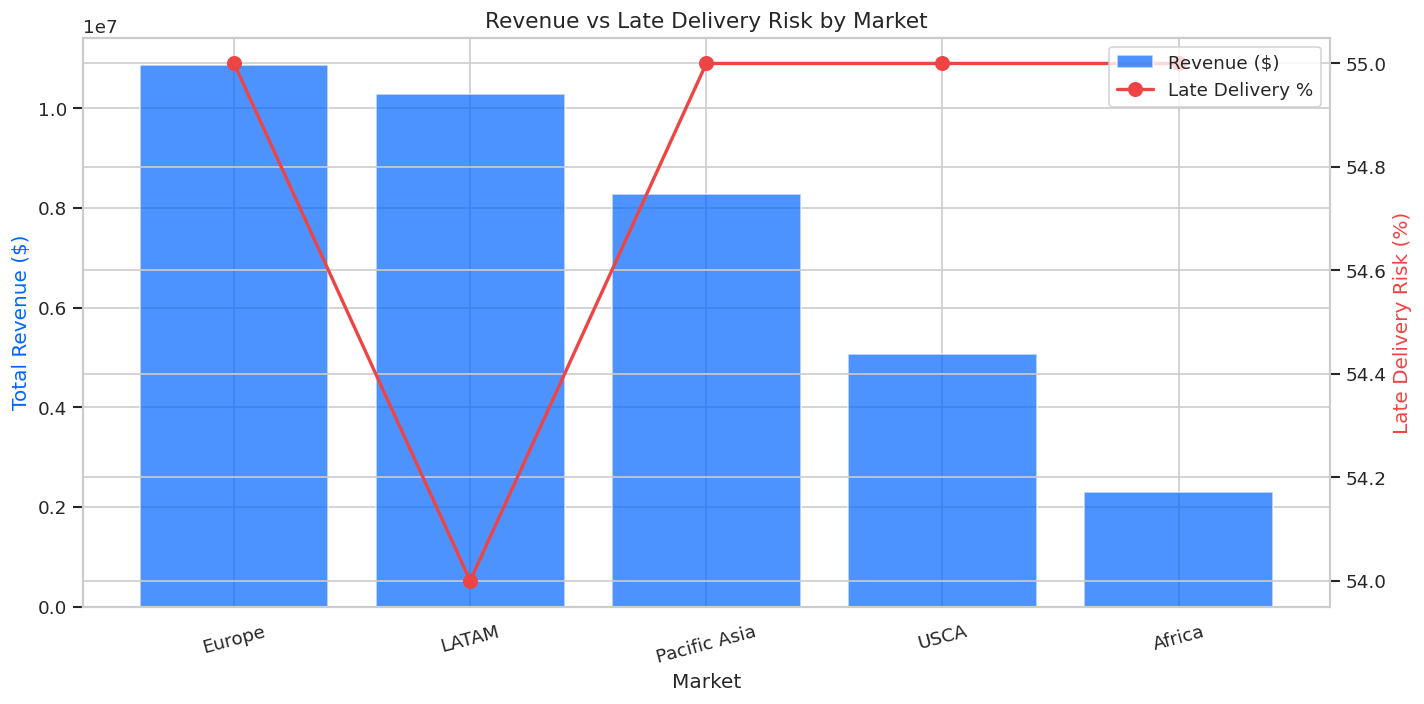

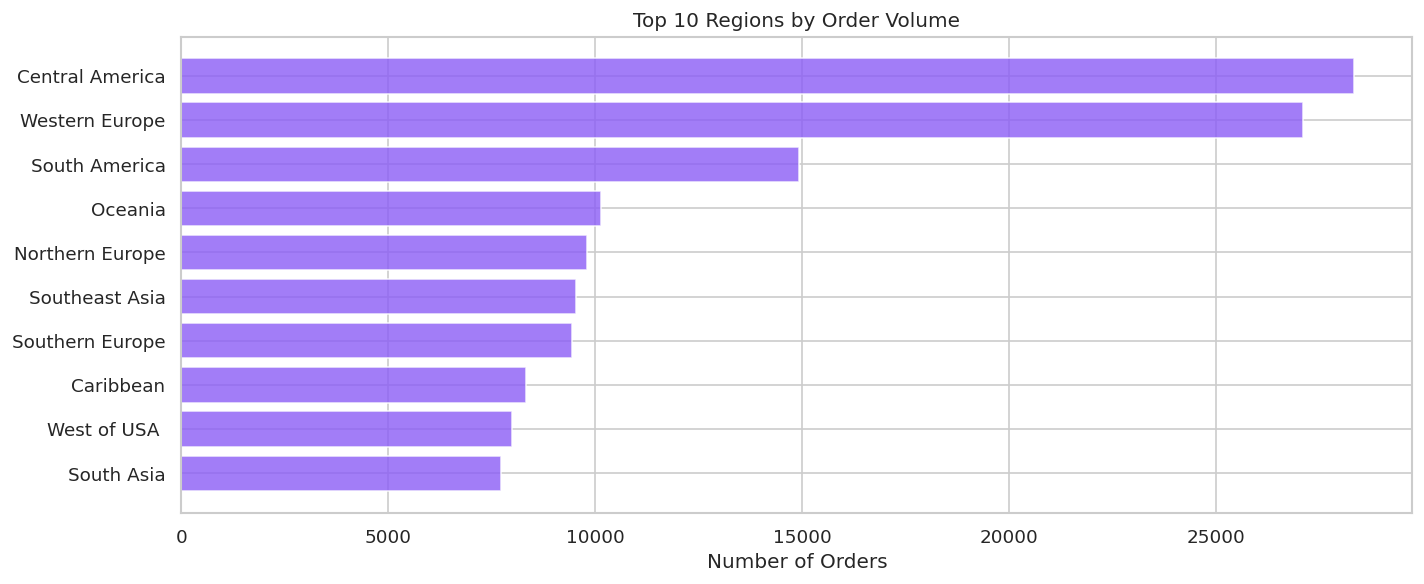

In [ ]:
# Orders by Market
market_summary = df.groupby('Market').agg(
orders=('Sales', 'count'),
revenue=('Sales', 'sum'),
avg_profit=('Benefit per order', 'mean'),
late_pct=('Late_delivery_risk', 'mean')
).round(2)
market_summary['late_pct'] = (market_summary['late_pct'] * 100).round(1)
market_summary = market_summary.sort_values('revenue', ascending=False)
print(market_summary)

# Grouped bar chart: Revenue + Late Delivery by Market
fig, ax1 = plt.subplots(figsize=(12, 6))
x = range(len(market_summary))
bars = ax1.bar(x, market_summary['revenue'], color='#0066FF', alpha=0.7, label='Revenue ($)')
ax1.set_xlabel('Market')
ax1.set_ylabel('Total Revenue ($)', color='#0066FF')
ax1.set_xticks(x)
ax1.set_xticklabels(market_summary.index, rotation=15)
ax2 = ax1.twinx() # second y-axis
ax2.plot(x, market_summary['late_pct'], color='#EF4444',
marker='o', linewidth=2, markersize=8, label='Late Delivery %')
ax2.set_ylabel('Late Delivery Risk (%)', color='#EF4444')
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.title('Revenue vs Late Delivery Risk by Market', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/market_revenue_vs_delay.png', dpi=150)
plt.show()

# Top 10 regions by order volume
region_orders = df['Order Region'].value_counts().head(10)
plt.figure(figsize=(12, 5))
plt.barh(region_orders.index[::-1], region_orders.values[::-1], color='#8B5CF6', alpha=0.8)
plt.title('Top 10 Regions by Order Volume')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.savefig('outputs/top_regions_orders.png', dpi=150)
plt.show()

 **10. Pareto Analysis & Root Cause**

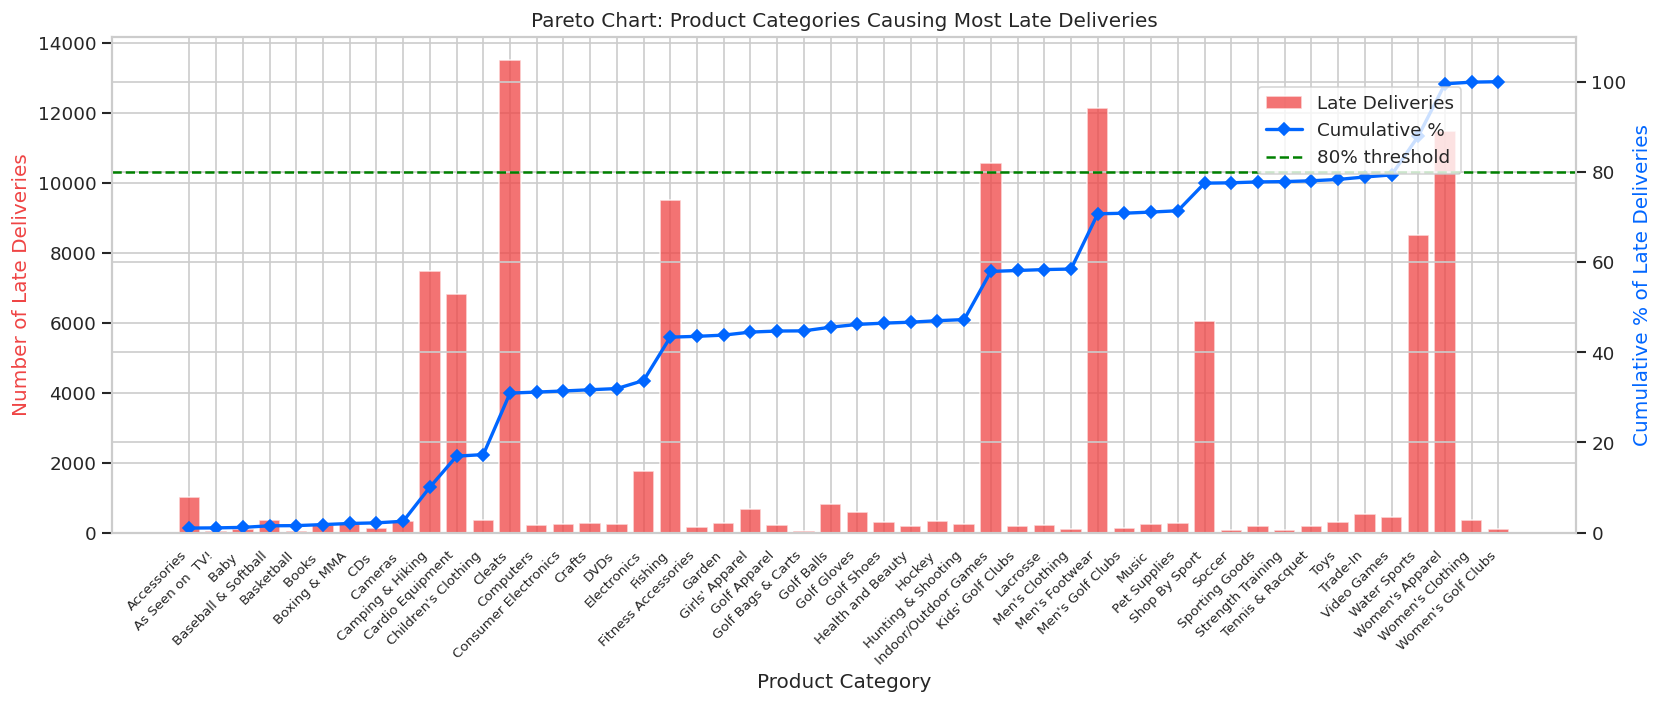

The top 46 categories account for 80% of all late deliveries:
['Accessories', 'As Seen on  TV!', 'Baby ', 'Baseball & Softball', 'Basketball', 'Books ', 'Boxing & MMA', 'CDs ', 'Cameras ', 'Camping & Hiking', 'Cardio Equipment', "Children's Clothing", 'Cleats', 'Computers', 'Consumer Electronics', 'Crafts', 'DVDs', 'Electronics', 'Fishing', 'Fitness Accessories', 'Garden', "Girls' Apparel", 'Golf Apparel', 'Golf Bags & Carts', 'Golf Balls', 'Golf Gloves', 'Golf Shoes', 'Health and Beauty', 'Hockey', 'Hunting & Shooting', 'Indoor/Outdoor Games', "Kids' Golf Clubs", 'Lacrosse', "Men's Clothing", "Men's Footwear", "Men's Golf Clubs", 'Music', 'Pet Supplies', 'Shop By Sport', 'Soccer', 'Sporting Goods', 'Strength Training', 'Tennis & Racquet', 'Toys', 'Trade-In', 'Video Games']


In [ ]:
# PARETO CHART: Which categories cause the most late deliveries?
cat_late = df.groupby('Category Name')['Late_delivery_risk'].sum()
cat_late_pct = cat_late.cumsum() / cat_late.sum() * 100
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(range(len(cat_late)), cat_late.values, color='#EF4444', alpha=0.75, label='Late Deliveries')
ax1.set_xlabel('Product Category')
ax1.set_ylabel('Number of Late Deliveries', color='#EF4444')
ax1.set_xticks(range(len(cat_late)))
ax1.set_xticklabels(cat_late.index, rotation=45, ha='right', fontsize=8)
ax2 = ax1.twinx()
ax2.plot(range(len(cat_late)), cat_late_pct.values,
color='#0066FF', marker='D', linewidth=2, markersize=5, label='Cumulative %')
ax2.axhline(y=80, color='green', linestyle='--', linewidth=1.5, label='80% threshold')
ax2.set_ylabel('Cumulative % of Late Deliveries', color='#0066FF')
ax2.set_ylim(0, 110)
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.title('Pareto Chart: Product Categories Causing Most Late Deliveries', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/pareto_late_deliveries.png', dpi=150, bbox_inches='tight')
plt.show()

# Print root cause summary
cutoff = cat_late_pct[cat_late_pct <= 80]
print(f'The top {len(cutoff)} categories account for 80% of all late deliveries:')
print(cutoff.index.tolist())

**11. Document Your Key Findings**

In [ ]:
# Generate automated EDA summary
print('=' * 60)
print('EDA SUMMARY REPORT — DataCo Supply Chain Dataset')
print('=' * 60)
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date Range: {df["order date (DateOrders)"].min().date()} to {df["order date (DateOrders)"].max().date()}')
print(f'Total Revenue: ${df["Sales"].sum():,.0f}')
print(f'Total Profit: ${df["Benefit per order"].sum():,.0f}')
print(f'Overall Profit Margin: {df["Benefit per order"].sum()/df["Sales"].sum()*100:.1f}%')
print(f'Late Delivery Rate: {df["Late_delivery_risk"].mean()*100:.1f}%')
print(f'Most Used Shipping Mode: {df["Shipping Mode"].mode()[0]}')
print(f'Top Market by Revenue: {df.groupby("Market")["Sales"].sum().idxmax()}')
print(f'Top Category by Profit: {df.groupby("Category Name")["Benefit per order"].sum().idxmax()}')
print(f'Most Orders from Segment: {df["Customer Segment"].mode()[0]}')

# Create 'order_month' column if it doesn't exist
if 'order_month' not in df.columns:
    df['order_month'] = df['order date (DateOrders)'].dt.month
print(f'Peak Order Month: {df["order_month"].mode()[0]}')
print(f'Loss-making Orders: {(df["Benefit per order"] < 0).sum():,} ({(df["Benefit per order"] < 0).mean()*100:.1f}%)')
print('=' * 60)

EDA SUMMARY REPORT — DataCo Supply Chain Dataset
Dataset: 180,519 rows x 54 columns
Date Range: 2015-01-01 to 2018-01-31
Total Revenue: $36,784,735
Total Profit: $3,966,903
Overall Profit Margin: 10.8%
Late Delivery Rate: 54.8%
Most Used Shipping Mode: Standard Class
Top Market by Revenue: Europe
Top Category by Profit: Fishing
Most Orders from Segment: Consumer
Peak Order Month: 1
Loss-making Orders: 33,784 (18.7%)
